# Algoritmos Supervisionados (MLP e KNN)

Este relatório descreve como aplicamos junto a uma rede neural MLP, a técnica de classificação KNN na base de dados Shuttle (Statlog). Também contém escolhas e justificativas dos parâmetros e técnicas utilizadas, assim como uma indicação objetiva de qual algoritmo é melhor para a base selecionada.

## Base de Dados Shuttle

A base de dados Shuttle contém informações sobre uma grande quantidade de dados relacionados ao transporte de astronautas no ônibus espacial Shuttle, e tarefa de classificação desse dataset envolve prever qual o tipo de falha ocorreu durante o processo.

### Características da Base de Dados

- **Número de amostras**: 58000 instâncias (linhas de dados).
- **Atributos**: 8 características, incluindo a variável alvo.
    - Flight Number (Número do vôo)
    - Altitude (Altitude do vôo)
    - Temperature (Temperatura no vôo)
    - Pressure (Pressão)
    - Wind (Vento)
    - Turbulence (Turbulência)
    - Fuel Type (Tipo de combustível)
- **Objetivo**: A tarefa principal é classificar o estado operacional do ônibus espacial, que é uma variável categórica com 7 classes possíveis, como operação normal, falha no sistema de propulsão, falha no sistema hidráulico, falha no sistema elétrico, entre outras.

### Comportamento em Algoritmos Supervisionados

O dataset Shuttle do Statlog é usado para classificação multiclasse com sete categorias, mas apresenta um desequilíbrio nas classes, onde algumas são muito mais frequentes que outras (1). Isso pode levar os algoritmos a favorecerem as classes majoritárias, dificultando a identificação das minoritárias. Como o conjunto é composto por variáveis numéricas de sensores, métodos como redes neurais, SVM e algoritmos baseados em árvores costumam ter bom desempenho.

## Análise Exploratória de Dados Shuttle

Neste relatório será realizada uma análise exploratória do dataset Shuttle do Statlog, com o objetivo de compreender melhor suas características antes da aplicação de algoritmos supervisionados. Serão apresentados dados gerais, como o número de amostras e atributos, além da verificação da presença de valores ausentes. Também será feita uma análise da distribuição da variável alvo, que representa os diferentes estados operacionais do ônibus espacial, bem como a distribuição das variáveis numéricas provenientes dos sensores. Ademais, exploraremos a correlação entre os atributos e a composição das variáveis categóricas, quando presentes. Esta análise inicial é essencial para identificar padrões, desequilíbrios nas classes e outras particularidades dos dados que podem impactar a escolha, o ajuste e o desempenho dos modelos de aprendizado supervisionado.

1. Carregamento e Primeira Visão dos Dados


In [11]:
# pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_shuttle = fetch_ucirepo(id=148) 
  
# data (as pandas dataframes) 
X = statlog_shuttle.data.features 
y = statlog_shuttle.data.targets 

# Estatísticas descritivas das features
print(X.describe())


           Rad Flow     Fpv Close      Fpv Open          High        Bypass  \
count  58000.000000  58000.000000  58000.000000  58000.000000  58000.000000   
mean      85.349121      0.259672     34.549862      1.608190     37.092310   
std        8.902769     36.521516     21.660139    217.597675     13.111428   
min       21.000000  -3939.000000   -188.000000 -26739.000000    -48.000000   
25%       79.000000      0.000000     26.000000     -5.000000     32.000000   
50%       83.000000      0.000000     42.000000      0.000000     39.000000   
75%       89.000000      0.000000     46.000000      5.000000     42.000000   
max      149.000000   3830.000000    436.000000  15164.000000    105.000000   

          Bpv Close      Bpv Open  
count  58000.000000  58000.000000  
mean      50.884552     13.932414  
std       21.418051     25.614018  
min     -353.000000   -356.000000  
25%       37.000000      0.000000  
50%       44.000000      2.000000  
75%       60.000000     14.000000  


2. Análise da Variável Alvo

class
1        45586
4         8903
5         3267
3          171
2           50
7           13
6           10
Name: count, dtype: int64


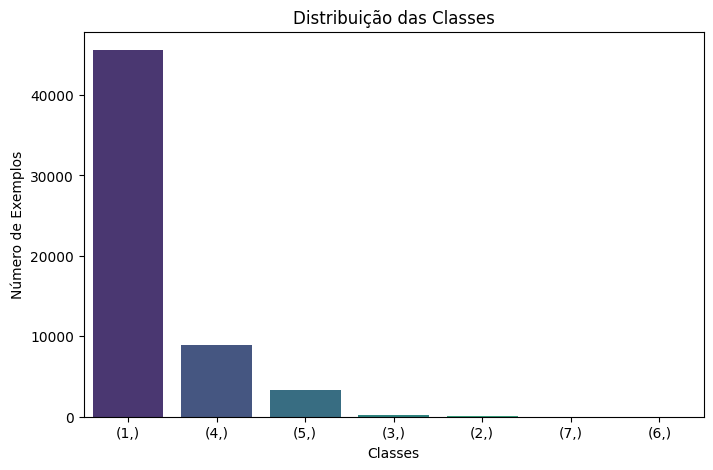

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar a contagem das classes
class_counts = y.value_counts()

print(class_counts)

# Converter índice para lista simples de strings (para evitar erros)
labels = class_counts.index.tolist()
labels = [str(label) for label in labels]

# Plotar o gráfico
plt.figure(figsize=(8, 5))
sns.barplot(x=labels, hue=labels, y=class_counts.values, palette="viridis")

plt.title("Distribuição das Classes")
plt.xlabel("Classes")
plt.ylabel("Número de Exemplos")
plt.show()

Esse gráfico nos mostra que a variável alvo é discreta, e não contínua. Ou seja, algoritmos de classificação são os mais indicados para agrupar essa base de dados. Por conta disso, vamos utilizar classificação para o KNN, e não regressão.

3. Análise das Variáveis Numéricas

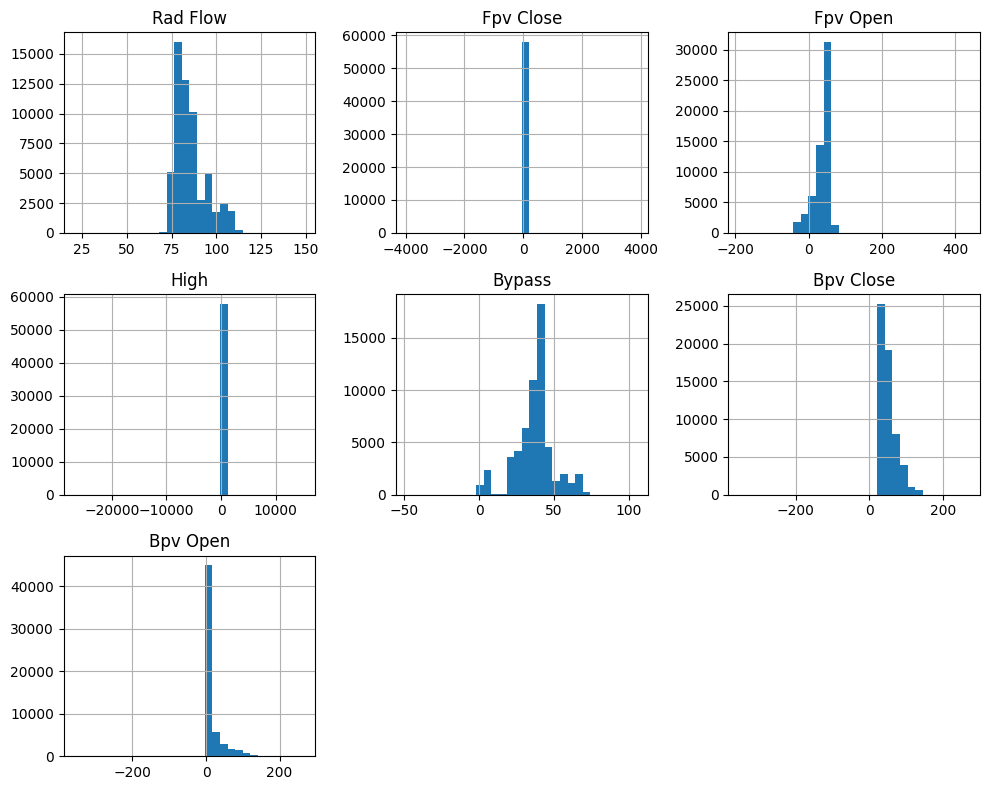

In [39]:
# Histograma de todas as variáveis

X.hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

4. Matriz de Correlação

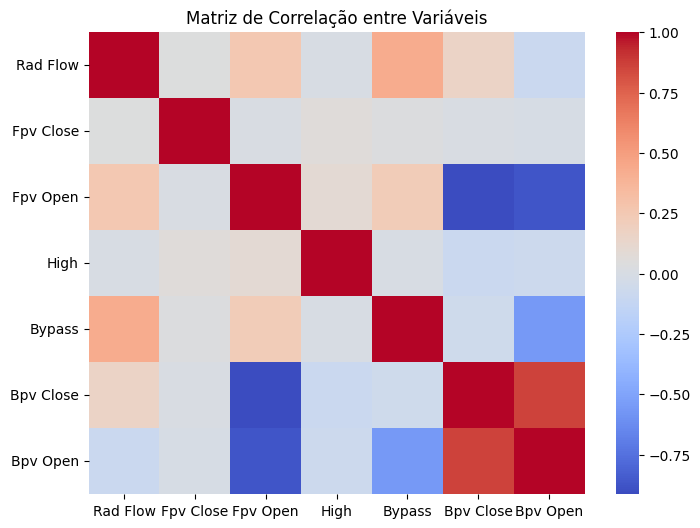

In [40]:
# Matriz de correlação
corr = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

## Algoritmo KNN

Primeiramente, precisamos decidir se vamos utilizar classificação ou regressão com o algoritmo KNN. Utilizamos classificação quando o rótulo for categórico ou discreto. Ou seja, quando desejamos prever uma categoria ou classe (por exemplo, 'sim' ou 'não', 'gato' ou 'cachorro'). O KNN irá prever a classe da nova amostra com base no voto da maioria dos seus k vizinhos mais próximos. Por outro lado, utilizamos regressão quando o rótulo for contínuo, ou seja, um número real (por exemplo: altura, preço, temperatura). Nesse caso, o KNN retorna a média (ou média ponderada) dos valores dos vizinhos mais próximos.

Dessa forma, decidimos utilizar o KNN para classificação por três motivos principais:

1. A variável-alvo do conjunto de dados Shuttle representa sete modos operacionais distintos da nave espacial, numerados de 1 a 7. Segundo a descrição da base no UCI Machine Learning Repository, esses valores inteiros indicam diferentes classes de modos de operação do sistema.

2. Os gráficos da análise preliminar mostram que a variável-alvo é discreta, com uma distribuição claramente categórica entre essas sete classes. Isso confirma que se trata de uma tarefa de classificação multiclasse.

3. O respositório analisado utiliza o algoritmo MLPClassifier, que é também um classificador. Comparar dois classificadores (MLPClassifier vs. KNN) mantém a coerência metodológica e permite avaliar desempenho em uma mesma tarefa supervisionada.

## Algoritmo MLP